# How to find `m` and `b` ?

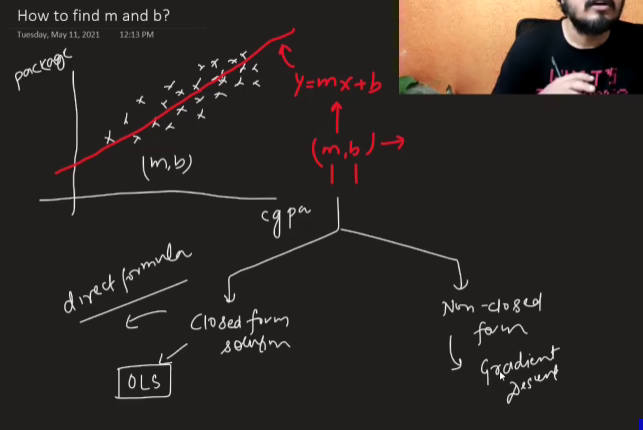

- There are 2 main methods to find `m` and `b`:

  1. **Closed Form Solution/ Ordinary Least Squares (OLS)** : where we have a mathematical formula to directly calculate `m` and `b` from the data
  
  2. **Non-closed Form Solution/ Gradient Descent** : where we use an iterative optimization algorithm to find the best `m` and `b` that minimize the error between the predicted and actual values 

## If we have a formula, why do we need an iterative method?

- In higher dimensions (multiple features), the closed form solution becomes computationally expensive and may not be feasible, whereas gradient descent can efficiently find the optimal parameters even in high-dimensional spaces.

- In sklearn, the `LinearRegression` class uses the closed form solution (OLS) to find the best fit line, so it directly calculates `m` and `b` without needing to use gradient descent.

- In sklearn, the `SGDRegressor` class uses stochastic gradient descent to find the best fit line, so it iteratively updates `m` and `b` until it converges to the optimal values.

- In this lecture, we will focus on the closed form solution (OLS) to find `m` and `b` for simple linear regression.

# Formula for OLS

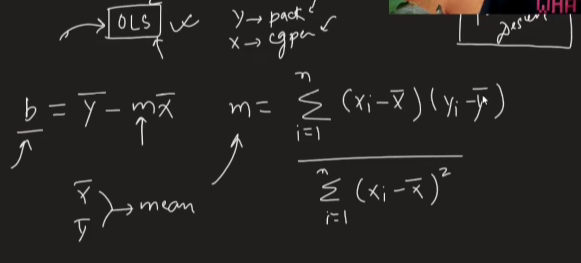

# Let's create the mathematical formulation of OLS from scratch

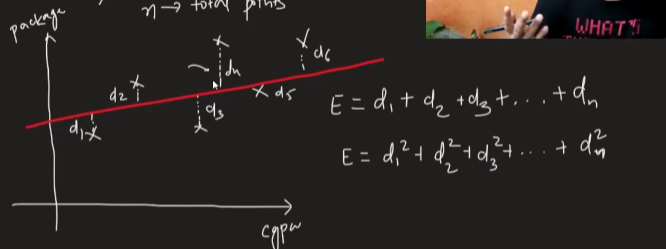

- we want to minimize the error between the predicted values and the actual values, so we can write the error as: squared error = (y - (mx + b))^2

- We took square because some points are above (positive error) and some points are below (negative error) the line, so if we take the sum of errors, they will cancel each other out, but if we take the square of errors, they will all be positive and we can minimize the total error.

## <span style="color:blue;">Why are we using squared error instead of absolute error?</span>

1. We want to penalize the outliers (like the points far from the line) more than the points close to the line, and squared error does that because it gives more weight to larger errors.

2. The absolute value of the error is not differentiable at the point where the error is zero, which makes it difficult to optimize using calculus

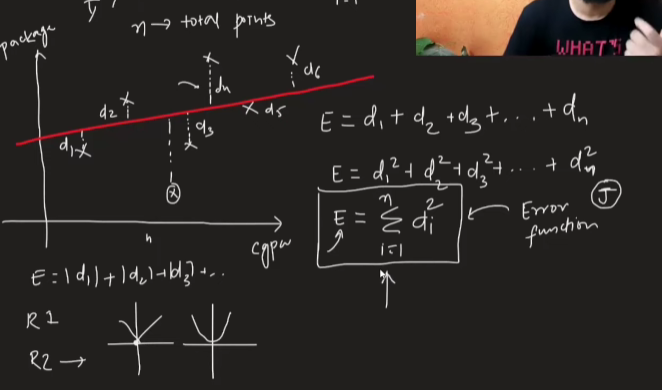

- So, we need to find m and b that minimize the the Error function (denoted by J(m,b) as well)
- We took total error, some place people take mean error as well, but it doesn't matter because we are minimizing the error, so the scale of the error doesn't matter, we just want to find the minimum point.

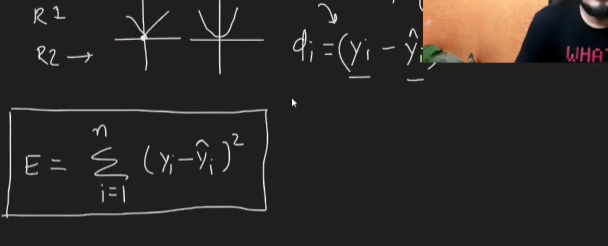

$$
E = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

---

### Meaning of Terms


$$
\begin{aligned}
y_i &: \text{Actual (observed) value of the } i^{\text{th}} \text{ data point} \\
\hat{y}_i &: \text{Predicted value of the } i^{\text{th}} \text{ data point} \\
n &: \text{Total number of data points} \\
E &: \text{Sum of Squared Errors}
\end{aligned}
$$

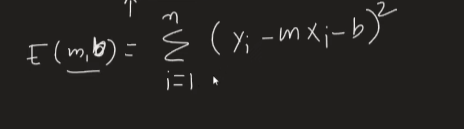

- here $y_i$ is constant, $x_i$ is constant, so we can take the derivative of $E$ with respect to $m$ and $b$, set it to zero and solve for $m$ and $b$ to find the minimum point.

# Let's see how change in `m` and `b` affects the error function

- E is function of `m` and `b`, so we can write it as E(m,b)
- So `m` and `b` are like knobs to tune the E

- We took b = 0, and we will see how E changes with respect to m

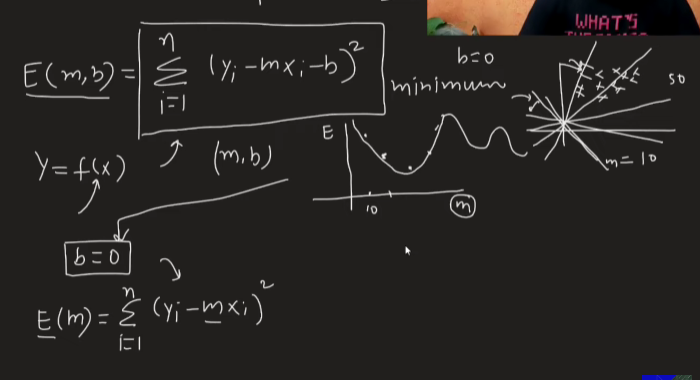

- We took m =1 and we will see how E changes with respect to b

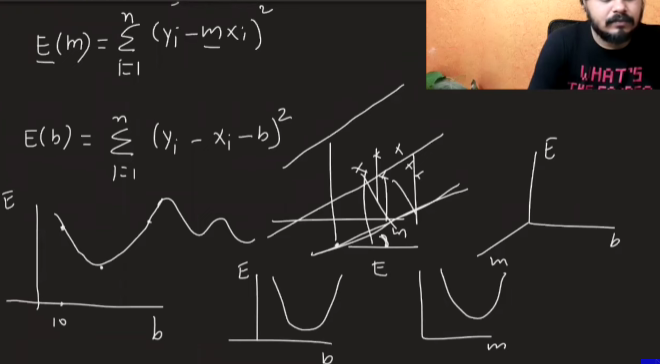

If we change both m and b, we will get a 3D surface plot of E(m,b)

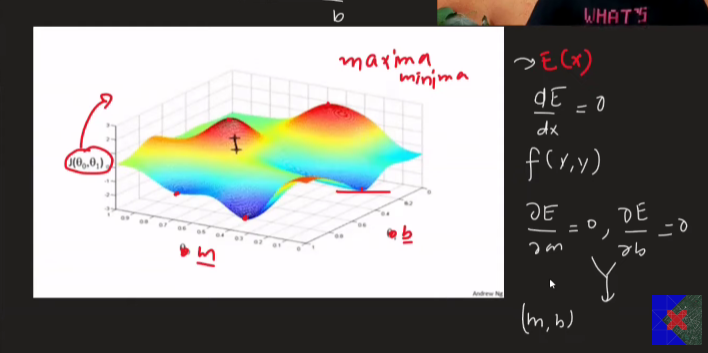

- Let's solve the partial derivatives of E with respect to m and b, set them to zero and solve for m and b to find the minimum point.

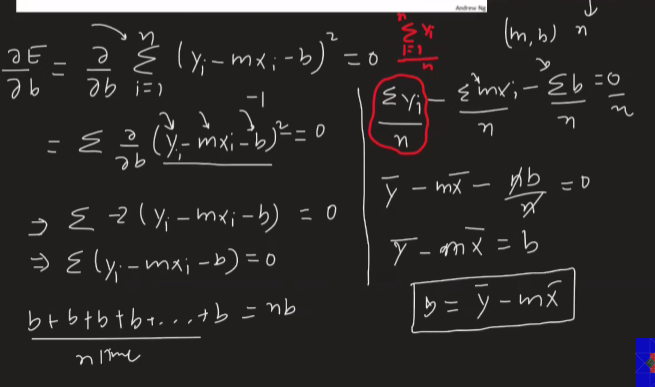

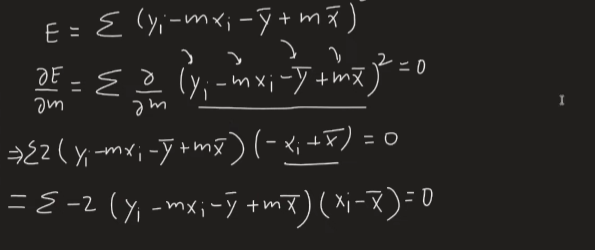

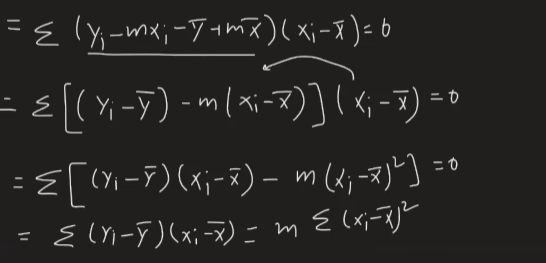

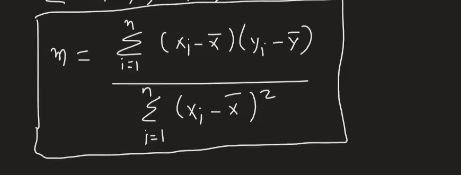

In [20]:
class MeraLR:
    
    def __init__(self):
        self.m = None
        self.b = None
        
    def fit(self,X_train,y_train):
        
        num = 0
        den = 0
        mean_x = X_train.mean()
        mean_y = y_train.mean()
        
        for i in range(X_train.shape[0]):
            
            num = num + ((X_train[i] - mean_x)*(y_train[i] - mean_y))
            den = den + ((X_train[i] - mean_x)*(X_train[i] - mean_x))
        
        self.m = num/den
        self.b = mean_y - (self.m * mean_x)
        print(self.m)
        print(self.b)       
    
    def predict(self,X_test):
        
        print(X_test)
        
        print(self.m * X_test + self.b)

In [21]:
import numpy as np
import pandas as pd

In [22]:
df = pd.read_csv('placement.csv')

In [23]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [24]:
X = df.iloc[:,0].values
y = df.iloc[:,1].values

In [25]:
X

array([6.89, 5.12, 7.82, 7.42, 6.94, 7.89, 6.73, 6.75, 6.09, 8.31, 5.32,
       6.61, 8.94, 6.93, 7.73, 7.25, 6.84, 5.38, 6.94, 7.48, 7.28, 6.85,
       6.14, 6.19, 6.53, 7.28, 8.31, 5.42, 5.94, 7.15, 7.36, 8.1 , 6.96,
       6.35, 7.34, 6.87, 5.99, 5.9 , 8.62, 7.43, 9.38, 6.89, 5.95, 7.66,
       5.09, 7.87, 6.07, 5.84, 8.63, 8.87, 9.58, 9.26, 8.37, 6.47, 6.86,
       8.2 , 5.84, 6.6 , 6.92, 7.56, 5.61, 5.48, 6.34, 9.16, 7.36, 7.6 ,
       5.11, 6.51, 7.56, 7.3 , 5.79, 7.47, 7.78, 8.44, 6.85, 6.97, 6.94,
       8.99, 6.59, 7.18, 7.63, 6.1 , 5.58, 8.44, 4.26, 4.79, 7.61, 8.09,
       4.73, 6.42, 7.11, 6.22, 7.9 , 6.79, 5.83, 6.63, 7.11, 5.98, 7.69,
       6.61, 7.95, 6.71, 5.13, 7.05, 7.62, 6.66, 6.13, 6.33, 7.76, 7.77,
       8.18, 5.42, 8.58, 6.94, 5.84, 8.35, 9.04, 7.12, 7.4 , 7.39, 5.23,
       6.5 , 5.12, 5.1 , 6.06, 7.33, 5.91, 6.78, 7.93, 7.29, 6.68, 6.37,
       5.84, 6.05, 7.2 , 6.1 , 5.64, 7.14, 7.91, 7.19, 7.91, 6.76, 6.93,
       4.85, 6.17, 5.84, 6.07, 5.66, 7.57, 8.28, 6.

In [26]:
y

array([3.26, 1.98, 3.25, 3.67, 3.57, 2.99, 2.6 , 2.48, 2.31, 3.51, 1.86,
       2.6 , 3.65, 2.89, 3.42, 3.23, 2.35, 2.09, 2.98, 2.83, 3.16, 2.93,
       2.3 , 2.48, 2.71, 3.65, 3.42, 2.16, 2.24, 3.49, 3.26, 3.89, 3.08,
       2.73, 3.42, 2.87, 2.84, 2.43, 4.36, 3.33, 4.02, 2.7 , 2.54, 2.76,
       1.86, 3.58, 2.26, 3.26, 4.09, 4.62, 4.43, 3.79, 4.11, 2.61, 3.09,
       3.39, 2.74, 1.94, 3.09, 3.31, 2.19, 1.61, 2.09, 4.25, 2.92, 3.81,
       1.63, 2.89, 2.99, 2.94, 2.35, 3.34, 3.62, 4.03, 3.44, 3.28, 3.15,
       4.6 , 2.21, 3.  , 3.44, 2.2 , 2.17, 3.49, 1.53, 1.48, 2.77, 3.55,
       1.48, 2.72, 2.66, 2.14, 4.  , 3.08, 2.42, 2.79, 2.61, 2.84, 3.83,
       3.24, 4.14, 3.52, 1.37, 3.  , 3.74, 2.82, 2.19, 2.59, 3.54, 4.06,
       3.76, 2.25, 4.1 , 2.37, 1.87, 4.21, 3.33, 2.99, 2.88, 2.65, 1.73,
       3.02, 2.01, 2.3 , 2.31, 3.16, 2.6 , 3.11, 3.34, 3.12, 2.49, 2.01,
       2.48, 2.58, 2.83, 2.6 , 2.1 , 3.13, 3.89, 2.4 , 3.15, 3.18, 3.04,
       1.54, 2.42, 2.18, 2.46, 2.21, 3.4 , 3.67, 2.

In [27]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [28]:
X_train.shape

(160,)

In [29]:
lr = MeraLR()

In [30]:
lr.fit(X_train,y_train)

0.5579519734250721
-0.8961119222429152


In [31]:
X_train[0]

np.float64(7.14)

In [32]:
X_train.mean()

np.float64(6.989937500000001)

In [33]:
X_test[0]

np.float64(8.58)

In [34]:
lr.predict(X_test[0])

8.58
3.891116009744203


- there is currently one problem with our code that its for simple linear regression, if we have multiple features, then we need to modify our code to handle that as well, but the intuition will remain the same, we will just have more parameters to optimize.

- Though the sklearn's `LinearRegression` class handles multiple features as well